# Brain Age Gap (BAG) and Lifestyle Factor Analysis

This notebook analyzes the relationship between Brain Age Gap (BAG) predictions
and various lifestyle/health factors, including age-varying associations.

## Workflow
1. Load BAG predictions and lifestyle covariates
2. Univariate analysis of BAG vs individual factors
3. Rolling window analysis to detect age-varying associations
4. Sensitivity analysis across different window parameters
5. Final visualizations

In [1]:
# Core imports
import numpy as np
import pandas as pd
from pathlib import Path
from itertools import product
from tqdm import tqdm

# Statistics
from scipy.stats import spearmanr, ttest_ind, f_oneway
import statsmodels.api as sm
from statsmodels.formula.api import wls, ols

# Visualization
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

# Neuroaging utilities
from neuroaging.utils import (
    setup_plotting,
    savefig_nice,
    COL_WEIGHTED,
    COL_RAW,
    COL_REF,
    compute_joint_poststrat_weights,
)

2026-01-14 11:09:44.457 | INFO     | neuroaging.config:<module>:11 - PROJ_ROOT path is: /home/galkepler/Projects/neuroaging


In [2]:
# Setup visualization
setup_plotting(font_path="/home/galkepler/.fonts/calibri-regular.ttf")

## 1. Configuration

In [3]:
# Paths
DATA_DIR = Path("/media/storage/phd/neuroaging/data")
OUTPUT_DIR = Path("/media/storage/phd/neuroaging/figures/revision/fig_BAG")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Target variable
TARGET = "stacked_BAG"

# Features to analyze
FEATURES = [
    # Psychological
    "psqi", "gad7", "phq9", "swls", "pcl5",
    # Personality
    "b5_extraversion", "b5_agreeableness", "b5_conscientiousness",
    "b5_emotional_stability", "b5_openness",
    # Health & Lifestyle
    "brain_health", "BMI", "weekly_workouts", "screen_time",
    "home_cooking_times_per_week", "has_pet",
    # Substances
    "smoking", "cannabis", "alcohol", "caffeine", "water",
    # Demographics
    "marital_status", "number_of_children", "relationship_duration",
    "living_environment", "education_level", "psychometric_score",
    # Brain structure
    "lateral_ventricles_mean",
]

# Features for detailed age-varying analysis
FEATURES_OF_INTEREST = ["lateral_ventricles_mean", "BMI", "alcohol"]

# Display names for plots
FEATURE_LABELS = {
    "BMI": "(B) BMI",
    "lateral_ventricles_mean": "(A) Lat. Vent. Volume",
    "caffeine": "Caffeine Intake",
    "alcohol": "(C) Alcohol Intake",
    "psqi": "(C) PSQI Score",
    "relationship_duration": "Relationship Duration",
    "number_of_children": "Number of Children",
    "water": "Water Intake",
}

# Sensitivity analysis parameters
GROUP_SIZES = [50, 75, 100, 150, 200]
STEPS = [5, 10, 15, 20]
CHOSEN_N, CHOSEN_S = 100, 10  # Primary parameters

## 2. Load Data

In [4]:
# Load BAG predictions
predictions_df = pd.read_csv("BAG_data.csv", index_col=0)

# Load population data for weighting
israel_population = pd.read_csv(DATA_DIR / "processed" / "israel_population.csv")

# Load covariate data
df_cov = pd.read_csv("~/Projects/plasticityhub/sessions.csv")
df_cov["subject_code"] = (
    df_cov["subject_code"]
    .astype(str)
    .str.replace("-", "")
    .str.replace(" ", "")
    .str.replace("_", "")
)
df_cov = df_cov.drop_duplicates(subset=["subject_code"]).set_index("subject_code")
df_cov["sex"] = df_cov["sex"].map({"M": 0, "F": 1})

# Merge predictions with covariates
df = df_cov.merge(predictions_df, left_on="subject_code", right_index=True, how="outer")
df = df.dropna(subset=[TARGET, "age_at_scan"])

print(f"Loaded {len(df)} subjects with BAG predictions")

Loaded 2795 subjects with BAG predictions


## 3. Feature Engineering

In [5]:
# Compute BMI
df["BMI"] = df["weight"] / ((df["height"] / 100) ** 2)

# Fill missing values for subjects who completed questionnaire
fill_cols = ["weekly_workouts", "home_cooking_times_per_week", "number_of_children", "relationship_duration"]
for col in fill_cols:
    if col in df.columns:
        df.loc[df["filled"].fillna(False), col] = df.loc[df["filled"].fillna(False), col].fillna(0)

# Handle smoking/cannabis missing values
df.loc[(df["smoking"] == False) & df["smoke_frequency_per_day"].isna(), "smoke_frequency_per_day"] = 0
df.loc[(df["cannabis"] == False) & df["canabis_frequency_per_week"].isna(), "canabis_frequency_per_week"] = 0

# Convert binary features
for col in ["has_pet", "smoking", "cannabis"]:
    if col in df.columns:
        df[col] = df[col].map({True: 1, False: 0, "True": 1, "False": 0})

# Encode education level
education_map = {
    "elementary school": 1, "partial high school": 2, "high_school": 3,
    "post-secondary": 4, "undergraduate": 5, "bachelor's degree": 6, "U": np.nan,
}
if "education_level" in df.columns:
    df["education_level"] = df["education_level"].map(education_map)

# Handle empty strings
df = df.replace("", pd.NA)

/tmp/ipykernel_20688/2930474362.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.loc[df["filled"].fillna(False), col] = df.loc[df["filled"].fillna(False), col].fillna(0)
/tmp/ipykernel_20688/2930474362.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.loc[df["filled"].fillna(False), col] = df.loc[df["filled"].fillna(False), col].fillna(0)
/tmp/ipykernel_20688/2930474362.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead

In [6]:
# Load FreeSurfer ventricle data if available
fs_template = "/media/storage/yalab-dev/derivatives/freesurfer/sub-{subj}/stats/aseg_stats.csv"

for subject in tqdm(df.index, desc="Loading FreeSurfer data"):
    fs_path = Path(fs_template.format(subj=subject))
    if fs_path.exists():
        fs_df = pd.read_csv(fs_path, sep="\t")
        for col in fs_df.columns:
            clean_col = col.lower().replace("-", "_").replace("3rd", "third").replace("4th", "fourth")
            df.loc[subject, clean_col] = fs_df.loc[0, col]

# Compute mean lateral ventricle volume
vent_cols = [c for c in df.columns if "lateral_ventricle" in c.lower()]
if vent_cols:
    df["lateral_ventricles_mean"] = df[vent_cols].mean(axis=1)

Loading FreeSurfer data: 100%|██████████| 2795/2795 [00:25<00:00, 109.23it/s]


## 4. Compute Post-stratification Weights

In [7]:
df["poststrat_weight"], _ = compute_joint_poststrat_weights(
    df,
    israel_population,
    age_col="age_at_scan",
    sex_col="sex",
    return_bin_table=True,
    cap=10,
)

# Center age for interaction models
df["age_centered"] = df["age_at_scan"] - df["age_at_scan"].mean()

## 5. Univariate Feature Analysis

In [8]:
results = []

for feature in FEATURES:
    if feature not in df.columns:
        continue

    n_missing = df[feature].isna().sum()
    feat_df = df.dropna(subset=[feature, TARGET]).copy()

    if len(feat_df) < 10:
        continue

    n_unique = feat_df[feature].nunique()

    if feat_df[feature].dtype == "object" or n_unique < 5:
        if n_unique == 2:  # Binary
            groups = [feat_df[feat_df[feature] == v][TARGET] for v in feat_df[feature].unique()]
            t, p = ttest_ind(*groups)
            d = (groups[1].mean() - groups[0].mean()) / groups[0].std() if groups[0].std() != 0 else 0
            results.append((feature, "binary", d, p, n_missing))
        else:  # Categorical
            groups = [feat_df[feat_df[feature] == v][TARGET] for v in feat_df[feature].unique()]
            f_val, p = f_oneway(*groups)
            eta2 = f_val * (len(groups) - 1) / (len(df) - len(groups) + f_val * (len(groups) - 1))
            results.append((feature, "categorical", eta2, p, n_missing))
    else:  # Continuous
        r, p = spearmanr(feat_df[feature], feat_df[TARGET])
        results.append((feature, "continuous", r, p, n_missing))

univariate_results = pd.DataFrame(
    results, columns=["Feature", "Type", "Effect Size", "p-value", "Missing"]
).sort_values("p-value")

display(univariate_results.head(15))

,Feature,Type,Effect Size,p-value,Missing
27,lateral_ventricles_mean,continuous,0.135685,3.975139e-12,202
22,number_of_children,continuous,-0.103257,8.082079e-07,522
23,relationship_duration,continuous,-0.094327,6.646955e-06,522
21,marital_status,categorical,0.010083,1.988481e-04,522
19,caffeine,continuous,0.077455,2.195067e-04,523
17,cannabis,binary,0.126730,1.645971e-02,566
13,screen_time,continuous,0.043625,4.248883e-02,632
16,smoking,binary,0.127860,4.287660e-02,563
20,water,continuous,0.039139,6.243344e-02,528
6,b5_agreeableness,continuous,0.034536,9.973416e-02,522


## 6. Rolling Window Analysis Functions

In [9]:
def rolling_window_analysis(df, x_col, target, group_size=100, step=10, weight_by_ess=False):
    """
    Perform windowed WLS to find how feature-BAG associations change over age.

    Parameters
    ----------
    df : DataFrame
        Data with features, target, age, and weights.
    x_col : str
        Feature column name.
    target : str
        Target column name (BAG).
    group_size : int
        Window size in number of subjects.
    step : int
        Step size for rolling window.
    weight_by_ess : bool
        Whether to weight meta-model by effective sample size.

    Returns
    -------
    bins_df : DataFrame
        Per-window results.
    mod_lin : statsmodels result
        Linear meta-model.
    mod_quad : statsmodels result
        Quadratic meta-model.
    """
    df_test = df[df[x_col].notna()].copy()
    df_test = df_test.sort_values("age_at_scan").reset_index(drop=True)

    results = []
    for i in range(0, len(df_test) - group_size + 1, step):
        group = df_test.iloc[i:i + group_size]

        formula = f"{target} ~ age_at_scan + {x_col}"
        res = wls(formula, data=group, weights=group["poststrat_weight"]).fit()

        w = group["poststrat_weight"]
        ess = (w.sum() ** 2) / (w ** 2).sum()

        results.append({
            "median_age": group["age_at_scan"].median(),
            "ess": ess,
            "min_age": group["age_at_scan"].min(),
            "max_age": group["age_at_scan"].max(),
            f"{x_col}_beta": res.params[x_col],
            f"{x_col}_p": res.pvalues[x_col],
            "window_p": res.f_pvalue,
        })

    bins_df = pd.DataFrame(results).astype(float)

    # Meta-modeling
    formula_lin = f"{x_col}_beta ~ median_age"
    formula_quad = f"{x_col}_beta ~ median_age + I(median_age ** 2)"

    if weight_by_ess:
        mod_lin = wls(formula_lin, data=bins_df, weights=bins_df["ess"]).fit()
        mod_quad = wls(formula_quad, data=bins_df, weights=bins_df["ess"]).fit()
    else:
        mod_lin = ols(formula_lin, data=bins_df).fit()
        mod_quad = ols(formula_quad, data=bins_df).fit()

    return bins_df, mod_lin, mod_quad

## 7. Run Sensitivity Analysis

In [10]:
pred_age = np.linspace(20, 60, 100)

for group_size, step in tqdm(product(GROUP_SIZES, STEPS), total=len(GROUP_SIZES) * len(STEPS)):
    out_dir = OUTPUT_DIR / f"N{group_size}_S{step}"
    out_dir.mkdir(parents=True, exist_ok=True)

    for feature in FEATURES_OF_INTEREST:
        out_file = out_dir / f"{feature}_windows.csv"
        if out_file.exists():
            continue

        bins_df, mod_lin, mod_quad = rolling_window_analysis(
            df, feature, TARGET, group_size=group_size, step=step
        )

        # Add model R² values
        bins_df["mod_lin_r2"] = mod_lin.rsquared
        bins_df["mod_quad_r2"] = mod_quad.rsquared

        # Save window results
        bins_df.to_csv(out_file, index=False)

        # Save trajectory predictions
        for model, name in [(mod_lin, "Lin"), (mod_quad, "Quad")]:
            pred_df = pd.DataFrame({"x": pred_age})
            if name == "Lin":
                pred_df["mean"] = model.predict({"median_age": pred_age})
            else:
                pred_df["mean"] = model.predict({"median_age": pred_age, "I(median_age ** 2)": pred_age ** 2})
            pred_df.to_csv(out_dir / f"{feature}_trajectory_{name}.csv", index=False)

100%|██████████| 20/20 [00:00<00:00, 752.05it/s]


## 8. Visualization: Age-Varying Associations

In [11]:
def plot_age_interaction(df, feature, target, output_dir):
    """Plot global interaction and rolling window trajectory."""
    feature_label = FEATURE_LABELS.get(feature, feature)
    feature_short = feature_label.split(")")[-1].strip() if ")" in feature_label else feature_label

    # Fit interaction model
    formula_int = f"{target} ~ {feature} * age_centered"
    formula_raw = f"{target} ~ {feature} + age_centered"
    res_int = wls(formula_int, data=df, weights=df["poststrat_weight"]).fit()
    res_raw = wls(formula_raw, data=df, weights=df["poststrat_weight"]).fit()
    f_stat, f_p, df_diff = res_int.compare_f_test(res_raw)

    # Format p-value
    if f_p < 1e-3:
        p_text = f"p < 1e{int(np.ceil(np.log10(f_p)))}"  
    elif f_p < 0.05:
        p_text = "p < 0.05"
    else:
        p_text = "n.s."

    # Create figure
    mpl.rcParams.update({"axes.labelsize": 35, "ytick.labelsize": 25, "xtick.labelsize": 25})
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))

    # Panel 1: Scatter with regression lines
    ax = axes[0]
    sns.scatterplot(data=df, x=feature, y=target, ax=ax, color=COL_REF, alpha=0.7, edgecolor="none")

    # Regression lines
    pred_x = np.linspace(df[feature].min(), df[feature].max(), 100)
    pred_df = pd.DataFrame({
        "age_at_scan": np.full(100, df["age_at_scan"].mean()),
        "age_centered": np.zeros(100),
        feature: pred_x,
    })

    for res, color, label in [(res_raw, COL_RAW, "No Int."), (res_int, COL_WEIGHTED, "Int.")]:
        y_pred = res.predict(pred_df)
        ax.plot(pred_x, y_pred, color=color, lw=6, label=label)

    ax.set_xlabel(feature_short)
    ax.set_ylabel("BAG (years)")
    ax.set_title(f"{feature_label}\n$F$={f_stat:.2f}, {p_text}", fontsize=35)
    ax.legend(frameon=False, fontsize=20)

    # Panel 2: Rolling window trajectory
    ax = axes[1]
    bins_df, mod_lin, mod_quad = rolling_window_analysis(df, feature, target, CHOSEN_N, CHOSEN_S)

    ax.scatter(bins_df["median_age"], bins_df[f"{feature}_beta"], s=100, color=COL_REF, alpha=0.7)

    # Plot quadratic fit
    x_pred = np.linspace(bins_df["median_age"].min(), bins_df["median_age"].max(), 100)
    y_pred = mod_quad.predict({"median_age": x_pred, "I(median_age ** 2)": x_pred ** 2})
    ax.plot(x_pred, y_pred, color=COL_WEIGHTED, lw=5, label=f"$R^2$={mod_quad.rsquared:.2f}")

    ax.axhline(0, color="black", linestyle="--", alpha=0.5)
    ax.set_xlabel("Median Age (years)")
    ax.set_ylabel(f"β ({feature_short})")
    ax.set_title("(II) Age-Varying Association", fontsize=35)
    ax.legend(frameon=False, fontsize=20)

    plt.tight_layout()
    savefig_nice(fig, output_dir / f"{feature}_analysis.png", dpi=300)

    return fig

In [12]:
# Generate plots for features of interest
for feature in FEATURES_OF_INTEREST:
    if feature in df.columns:
        plot_age_interaction(df, feature, TARGET, OUTPUT_DIR)

findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeOneSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeTwoSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeThreeSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFourSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFiveSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmsy10'] not

## 9. Sensitivity Trajectory Visualization

In [13]:
def plot_sensitivity_trajectories(feature, feature_df, lin_preds, quad_preds):
    """Plot sensitivity analysis across different window parameters."""
    feature_label = FEATURE_LABELS.get(feature, feature)
    feature_short = feature_label.split(")")[-1].strip() if ")" in feature_label else feature_label

    fig, axes = plt.subplots(1, 3, figsize=(29, 9), width_ratios=[1, 1, 0.5])
    axes[1].sharey(axes[0])

    # Color palette for different N values
    unique_ns = sorted(lin_preds["N"].unique())
    gray_palette = {n: plt.cm.gist_gray_r(x) for n, x in zip(unique_ns, np.linspace(0.3, 0.7, len(unique_ns)))}

    for preds, ax, title in [(lin_preds, axes[0], "(I) Linear"), (quad_preds, axes[1], "(II) Quadratic")]:
        # Background: all sensitivity lines
        sns.lineplot(data=preds[preds["x"] <= 85], x="x", y="mean", hue="N",
                     palette=gray_palette, alpha=0.85, lw=2.5, ax=ax, legend=True)

        # Highlight primary setting
        primary = preds[(preds["N"] == CHOSEN_N) & (preds["step"] == CHOSEN_S)]
        sns.lineplot(data=primary, x="x", y="mean", color=COL_WEIGHTED, lw=5, ax=ax,
                     label=f"Primary (N={CHOSEN_N}, S={CHOSEN_S})")

        ax.axhline(0, color="black", linestyle="--", lw=2, alpha=0.5)
        ax.set_xlabel("Median Age (years)")
        ax.set_ylabel(f"β ({feature_short})")
        ax.set_title(title, fontsize=35)
        ax.legend(title="Group Size (N)", fontsize=16, title_fontsize=18, loc="lower right")

    # Panel 3: Parameter correlation
    ax = axes[2]
    corr_matrix = feature_df.pivot_table(index="N", columns="step", values="mod_quad_r2")
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdYlGn", ax=ax,
                cbar_kws={"label": "$R^2$"})
    ax.set_xlabel("Step Size")
    ax.set_ylabel("Group Size (N)")
    ax.set_title("(III) Parameter Sensitivity", fontsize=35)

    fig.suptitle(feature_label, fontsize=40, y=0.98, x=0.5)
    plt.tight_layout()

    return fig

KeyError: 'x'

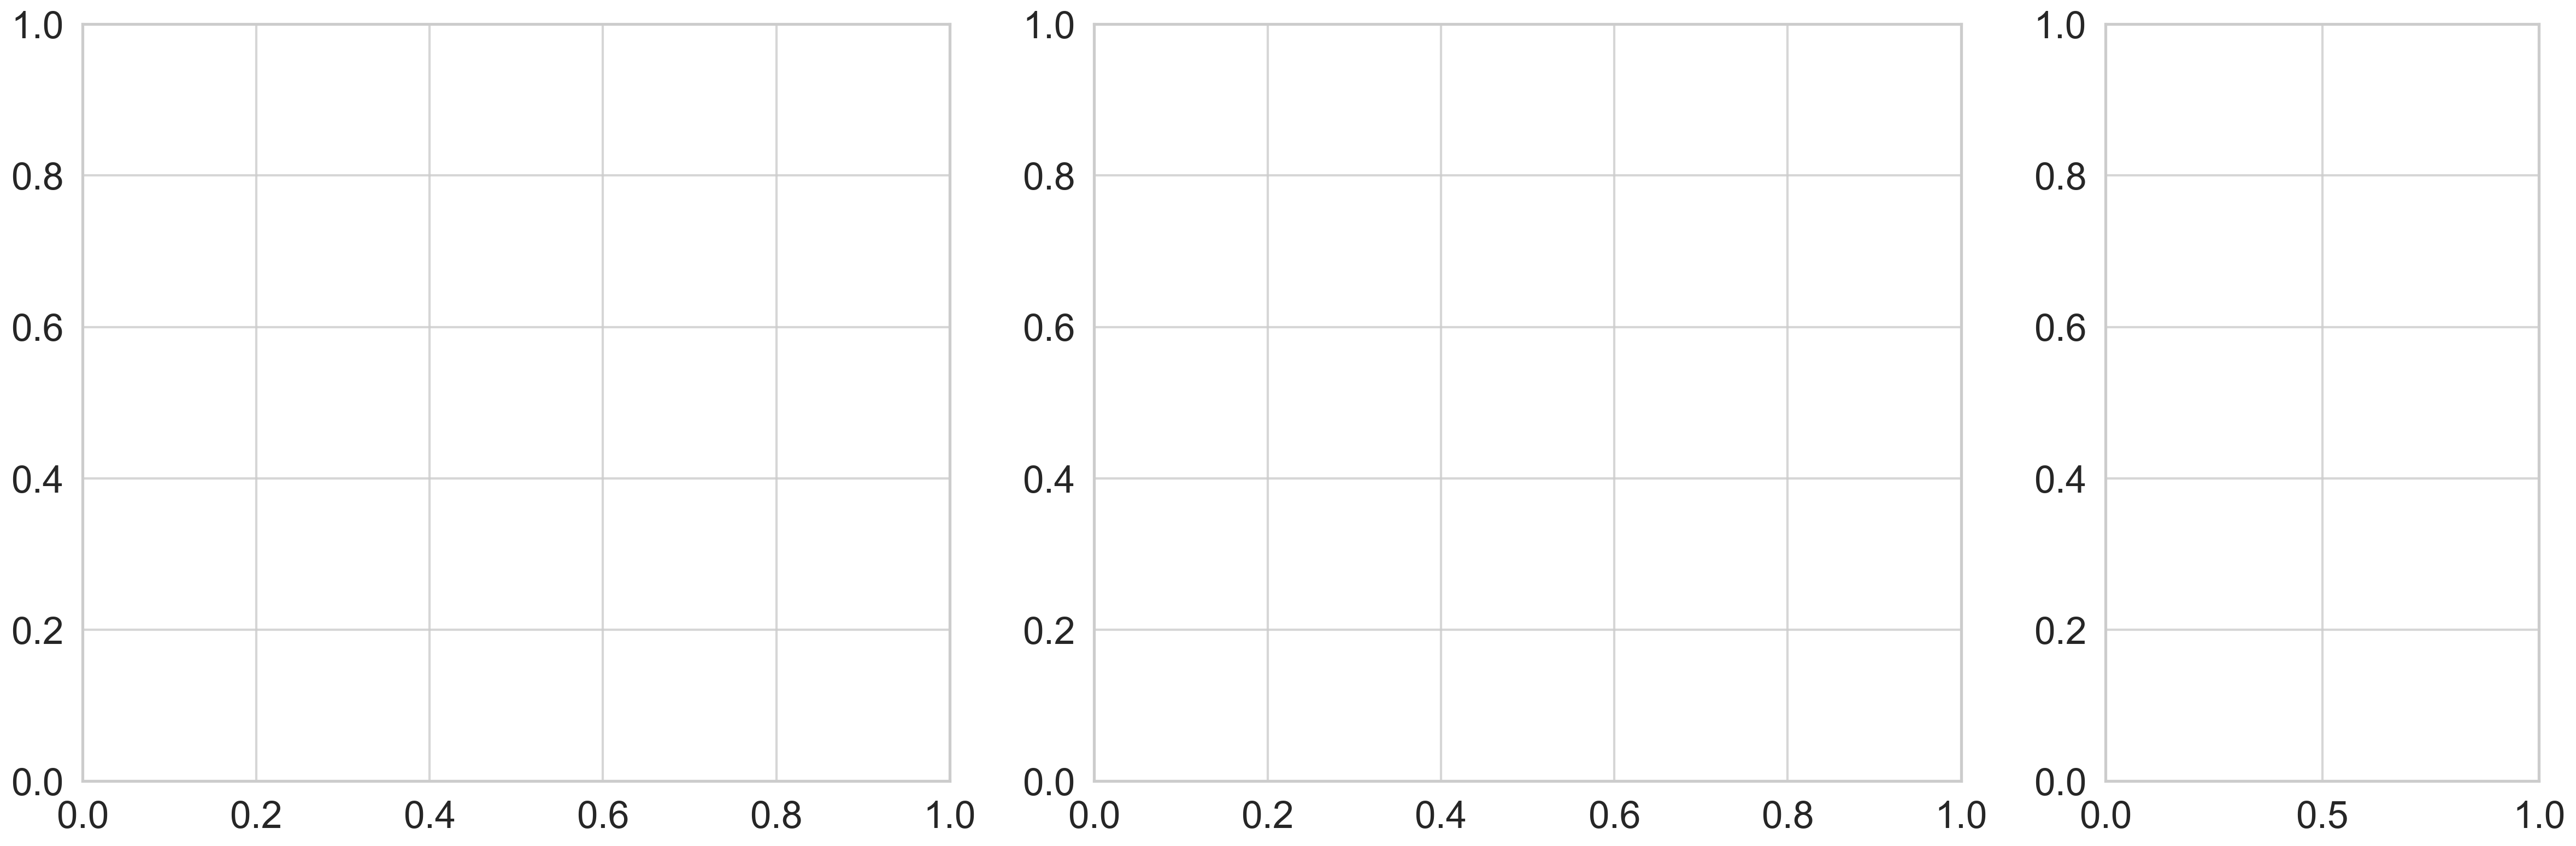

In [14]:
for feature in FEATURES_OF_INTEREST:
    feature_df = []
    lin_preds = []
    quad_preds = []

    for group_size, step in product(GROUP_SIZES, STEPS):
        out_dir = OUTPUT_DIR / f"N{group_size}_S{step}"

        # Load window results
        bins_path = out_dir / f"{feature}_windows.csv"
        if not bins_path.exists():
            continue

        bins_df = pd.read_csv(bins_path)
        bins_df["N"] = group_size
        bins_df["step"] = step
        feature_df.append(bins_df)

        # Load trajectory predictions
        for model, target_list in [("Lin", lin_preds), ("Quad", quad_preds)]:
            traj_path = out_dir / f"{feature}_trajectory_{model}.csv"
            if traj_path.exists():
                pred_df = pd.read_csv(traj_path)
                pred_df["N"] = group_size
                pred_df["step"] = step
                target_list.append(pred_df)

    if feature_df:
        feature_df = pd.concat(feature_df, axis=0)
        lin_preds = pd.concat(lin_preds, axis=0)
        quad_preds = pd.concat(quad_preds, axis=0)

        fig = plot_sensitivity_trajectories(feature, feature_df, lin_preds, quad_preds)
        savefig_nice(fig, OUTPUT_DIR / f"{feature}_sensitivity.png", dpi=400)

In [15]:
feature_df

,median_age,ess,min_age,max_age,lateral_ventricles_mean_beta,lateral_ventricles_mean_p,window_p,mod_lin_r2,mod_quad_r2,mod_lin_p,...,mod_lin_se_median_age,mod_quad_beta_Intercept,mod_quad_se_Intercept,mod_quad_beta_median_age,mod_quad_se_median_age,mod_quad_beta_I(median_age ** 2),mod_quad_se_I(median_age ** 2),feature,N,step
0,18.490,49.097467,18.02,19.29,3.423512,2.145528e-01,2.563829e-01,0.165151,0.222788,1.389850e-21,...,0.012767,-7.684060,1.300103,0.568181,0.073113,-0.005810,0.000950,lateral_ventricles_mean,50,5
1,18.730,49.094049,18.14,19.49,4.269228,2.137180e-01,4.407002e-01,0.165151,0.222788,1.389850e-21,...,0.012767,-7.684060,1.300103,0.568181,0.073113,-0.005810,0.000950,lateral_ventricles_mean,50,5
2,18.830,49.101514,18.26,19.74,3.632814,3.274565e-01,5.847860e-01,0.165151,0.222788,1.389850e-21,...,0.012767,-7.684060,1.300103,0.568181,0.073113,-0.005810,0.000950,lateral_ventricles_mean,50,5
3,19.055,49.120328,18.36,19.86,3.686608,3.162931e-01,4.152376e-01,0.165151,0.222788,1.389850e-21,...,0.012767,-7.684060,1.300103,0.568181,0.073113,-0.005810,0.000950,lateral_ventricles_mean,50,5
4,19.230,47.468607,18.44,20.06,1.967624,6.338830e-01,2.457308e-01,0.165151,0.222788,1.389850e-21,...,0.012767,-7.684060,1.300103,0.568181,0.073113,-0.005810,0.000950,lateral_ventricles_mean,50,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,48.585,172.837293,44.15,57.55,4.931144,3.755806e-05,3.867575e-05,0.575426,0.690583,1.075802e-23,...,0.013152,-10.628715,1.476974,0.747495,0.088791,-0.008337,0.001263,lateral_ventricles_mean,200,20
116,49.665,170.985537,44.76,60.96,5.419407,2.521768e-06,1.985928e-06,0.575426,0.690583,1.075802e-23,...,0.013152,-10.628715,1.476974,0.747495,0.088791,-0.008337,0.001263,lateral_ventricles_mean,200,20
117,50.800,167.915345,45.56,64.32,5.796653,4.222211e-08,2.655175e-07,0.575426,0.690583,1.075802e-23,...,0.013152,-10.628715,1.476974,0.747495,0.088791,-0.008337,0.001263,lateral_ventricles_mean,200,20
118,52.800,169.423170,46.71,69.50,6.425510,1.770044e-08,1.236654e-07,0.575426,0.690583,1.075802e-23,...,0.013152,-10.628715,1.476974,0.747495,0.088791,-0.008337,0.001263,lateral_ventricles_mean,200,20


## 10. Summary Statistics

In [ ]:
# Display top significant features
sig_features = univariate_results[univariate_results["p-value"] < 0.05]
print(f"\n{len(sig_features)} features significantly associated with BAG (p < 0.05):")
display(sig_features)